**Import modules**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import zipfile as zf

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print("Done importing modules....")

Done importing modules....


In [4]:
# unzip file

# zip_path = '../data/loan_data.zip'
# extract_path = '../data/'

# with zf.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

**Initial Look on the Data**

In [5]:
# create df for train dataset

train_csv_path = '../data/train.csv'

train_df = pd.read_csv(train_csv_path)

print("Dataframe successfully created...")

Dataframe successfully created...


In [6]:
# inspect shape
row, col = train_df.shape
print(f'Number of Rows: {row}')
print(f'Number of Columns: {col} \n')

# display metadata
train_df.info()
print()

Number of Rows: 614
Number of Columns: 13 

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB



**Initial observation:** 

The dataset contains **614 rows and 13 columns.**
Missing values are present in several features: Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History.

These issues will be addressed during the data preprocessing stage to ensure consistency and compatibility with the subsequent analysis and machine learning workflow.

In [7]:
# first five rows
print('First 5 rows: ')
display(train_df.head())
print("\n")

print('Last 5 rows: ')
display(train_df.tail())

First 5 rows: 


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y




Last 5 rows: 


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [8]:
# dtypes
train_df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [9]:
# count unique values in each column
train_df.nunique().sort_values(ascending=False)

Loan_ID              614
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Dependents             4
Property_Area          3
Gender                 2
Married                2
Education              2
Self_Employed          2
Credit_History         2
Loan_Status            2
dtype: int64

In [10]:
# frequency distribution of unique rows
train_df.value_counts()

Loan_ID   Gender  Married  Dependents  Education     Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  Property_Area  Loan_Status
LP001003  Male    Yes      1           Graduate      No             4583             1508.000000        128.0       360.0             1.0             Rural          N              1
LP001005  Male    Yes      0           Graduate      Yes            3000             0.000000           66.0        360.0             1.0             Urban          Y              1
LP001006  Male    Yes      0           Not Graduate  No             2583             2358.000000        120.0       360.0             1.0             Urban          Y              1
LP001008  Male    No       0           Graduate      No             6000             0.000000           141.0       360.0             1.0             Urban          Y              1
LP001011  Male    Yes      2           Graduate      Yes            5417             4196.00000

In [11]:
# descriptive statistics
train_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.46,6109.04,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.25,2926.25,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.41,85.59,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.00,65.12,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.84,0.36,0.0,1.0,1.0,1.00,1.0


In [12]:
# loan amount term
train_df['Loan_Amount_Term'].value_counts().sort_index(ascending=False)

Loan_Amount_Term
480.0     15
360.0    512
300.0     13
240.0      4
180.0     44
120.0      3
84.0       4
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [13]:
# credit history
train_df['Credit_History'].value_counts(dropna=False)

Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64

**Initial Observation:**

* **ApplicantIncome:** The average applicant income is 5,403.46, with a standard deviation of 6,109.04, indicating substantial variability. The median is 3,812.50, while the middle 50% of incomes range from 2,877.50 to 5,795.00. Incomes range from 150 to 81,000. The higher mean and maximum value suggest a right-skewed distribution with potential high-income outliers.

* **CoapplicantIncome:** The average coapplicant income is 1,621.25, with a standard deviation of 2,926.25, indicating substantial variability. At least 25% of applicants have no coapplicant income, as the first quartile is 0. The median is 1,188.50, while the middle 50% range from 0 to 2,297.25. Incomes range from 0 to 41,667. The higher mean and maximum value suggest a right-skewed distribution with potential high-income outliers.

* **LoanAmount:** The average loan amount is 146.41, with a standard deviation of 85.59, indicating considerable variability. The median is 128, while the middle 50% of loan amounts range from 100 to 168. Loan amounts range from 9 to 700. The higher mean and maximum value suggest a right-skewed distribution with potential high-value outliers.

* **Loan_Amount_Term:** The average loan term is 342 months, with a standard deviation of 65.12. The median and all quartiles are 360 months, indicating that the data is highly concentrated at 360 months. Of the 600 non-missing observations, 512 (85.3%) have a 360-month term. The lower mean suggests that shorter loan terms pull the distribution toward the left.

* **Credit_History:** Of the 564 non-missing observations, 475 (84.2%) have a value of 1 and 89 (15.8%) have a value of 0. This indicates that the variable is highly concentrated at 1. There are also 50 missing values, representing approximately 8.1% of the dataset.


In [14]:
# descriptive statistics for categorical values
train_df.describe(include=object).T

,count,unique,top,freq
Loan_ID,614,614,LP001002,1
Gender,601,2,Male,489
Married,611,2,Yes,398
Dependents,599,4,0,345
Education,614,2,Graduate,480
Self_Employed,582,2,No,500
Property_Area,614,3,Semiurban,233
Loan_Status,614,2,Y,422


In [15]:
# to prevent alteration
train_copy = train_df.copy()

# display uique values and frequencies per categorical column
train_copy.select_dtypes(include='object').columns.tolist()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [47]:
# frequencies and unique values of categorical features
cat_cols = train_copy.select_dtypes(include='object').drop(columns=['Loan_ID'])

def main():
    display_unique_and_freq(cat_cols)
    

def display_unique_and_freq(df):
    for col in df.columns:
        unique = df[col].nunique()
        freq = df[col].value_counts(dropna=False)
        
        print('=====' * 10)
        print(f'Number of unique values in {col}: {unique} \n')
        print(f'Frequency of each category in {col}:')
        print(freq, '\n')
    

main()

Number of unique values in Gender: 2 

Frequency of each category in Gender:
Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64 

Number of unique values in Married: 2 

Frequency of each category in Married:
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64 

Number of unique values in Dependents: 4 

Frequency of each category in Dependents:
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64 

Number of unique values in Education: 2 

Frequency of each category in Education:
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64 

Number of unique values in Self_Employed: 2 

Frequency of each category in Self_Employed:
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64 

Number of unique values in Property_Area: 3 

Frequency of each category in Property_Area:
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64 

Number o

In [17]:
# inspect dtypes
cat_cols.dtypes

Gender           str
Married          str
Dependents       str
Education        str
Self_Employed    str
Property_Area    str
Loan_Status      str
dtype: object

**Exploratory Data Analysis**

In [18]:
# inspect df if there are duplicates
has_duplicates = train_copy.duplicated().any()
print(f'Are there duplicates in the dataset?: {has_duplicates} \n')


duplicate_count = train_copy.duplicated().sum()
print(f'Number of duplicates: {duplicate_count}')

Are there duplicates in the dataset?: False 

Number of duplicates: 0


In [19]:
# check missing values
train_copy.isnull().sum().sort_values(ascending=False)

Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
Loan_ID               0
CoapplicantIncome     0
ApplicantIncome       0
Property_Area         0
Loan_Status           0
dtype: int64

In [20]:
# sanity check for missing values
train_copy.isnull().any().sort_values(ascending=False)

Gender                True
Married               True
Dependents            True
Self_Employed         True
LoanAmount            True
Loan_Amount_Term      True
Credit_History        True
Loan_ID              False
Education            False
ApplicantIncome      False
CoapplicantIncome    False
Property_Area        False
Loan_Status          False
dtype: bool

**Initial Observation:**

The dataset contains missing values in seven features, with missingness ranging from 0.49% to 8.14%. Credit_History has the highest missing-value percentage at 8.14%, while Loan_Status and several other features have no missing values. No duplicate rows were found in the dataset.

In [21]:
# calculate percentage of missing values
missing = pd.DataFrame(
    {
        'Missing_Count': train_copy.isnull().sum(),
        'Missing_Percentage': (train_copy.isnull().sum() / len(train_copy) * 100).round(2)
    }
)

missing = missing.sort_values('Missing_Count', ascending=False)
display(missing)

,Missing_Count,Missing_Percentage
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49
Education,0,0.00
Loan_ID,0,0.00
CoapplicantIncome,0,0.00


**Univariate Analysis**

In [22]:
# separate columns
num_cols = train_copy.select_dtypes(include='number')
cat_cols = train_copy.select_dtypes(include='object').drop(
    columns=[
        'Loan_ID', 'Loan_Status'
        ]
    )

**Numerical Univariate Analysis**

This section aims to understand:
- Distribution - how values are spread
- Skewness - whether the distribution is symmetric or leans toward one side
- Central tendency - where the values are generally centered (mean/median)
- Range - the spread between the minimum and maximum values
- Potential outliers - unusually high or low observations

In [23]:
# numerical statistics
summary = pd.DataFrame(
    {
        'Mean': num_cols.mean(),
        'Median': num_cols.median(),
        'Mode': num_cols.mode().iloc[0],
        'Variance': num_cols.var(),
        'Std': num_cols.std(),
        'Minimum': num_cols.min(),
        'Max': num_cols.max(),
        'Range': num_cols.max() - num_cols.min(),
        'Skewness': num_cols.skew()
    }
)

display((summary).round(2))

,Mean,Median,Mode,Variance,Std,Minimum,Max,Range,Skewness
ApplicantIncome,5403.46,3812.5,2500.0,37320390.17,6109.04,150.0,81000.0,80850.0,6.54
CoapplicantIncome,1621.25,1188.5,0.0,8562929.52,2926.25,0.0,41667.0,41667.0,7.49
LoanAmount,146.41,128.0,120.0,7325.19,85.59,9.0,700.0,691.0,2.68
Loan_Amount_Term,342.00,360.0,360.0,4240.67,65.12,12.0,480.0,468.0,-2.36
Credit_History,0.84,1.0,1.0,0.13,0.36,0.0,1.0,1.0,-1.88


**Interpretations:**

* **ApplicantIncome:** The mean income of 5,403.46 is higher than the median of 3,812.50, indicating that the distribution is right-skewed. This is supported by the high positive skewness value of 6.54, which indicates a long right tail. The standard deviation of 6,109.04 indicates substantial variability in applicant income. The mode is 2,500, indicating that 2,500 is the most frequently occurring applicant income value in the dataset.

* **CoapplicantIncome:** The mean coapplicant income of 1,621.25 is higher than the median of 1,188.50, suggesting that the distribution is also right-skewed. This is supported by the positive skewness value of 7.49. The standard deviation of 2,926.25 indicates substantial variability in coapplicant income. The mode of 0 indicates that zero coapplicant income is the most frequently occurring value.

* **LoanAmount:** The mean of 146.41 is higher than the median of 128.00, indicating a right-skewed distribution. This is supported by the positive skewness value of 2.68. The standard deviation of 85.59 indicates considerable variability in loan amounts.

* **Loan_Amount_Term:** The mean of 342 is lower than the median of 360, indicating that the distribution is left-skewed. This is supported by the negative skewness value of -2.36. The standard deviation of 65.12 indicates some variability in the loan terms.

* **Credit_History:** The mean of 0.84, along with a median and mode of 1, indicates that most observations have a value of 1. Since this variable is binary, with values of 0 and 1, the mean represents the proportion of observations with a value of 1. The standard deviation of 0.36 reflects the variability between the two possible values. The negative skewness of -1.88 reflects the concentration of observations at 1.


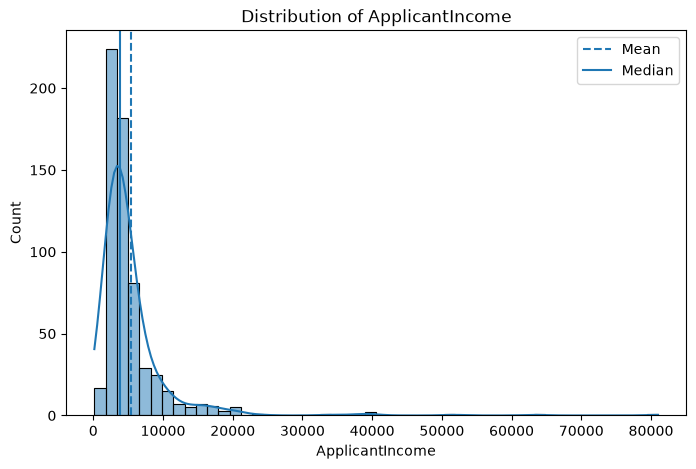

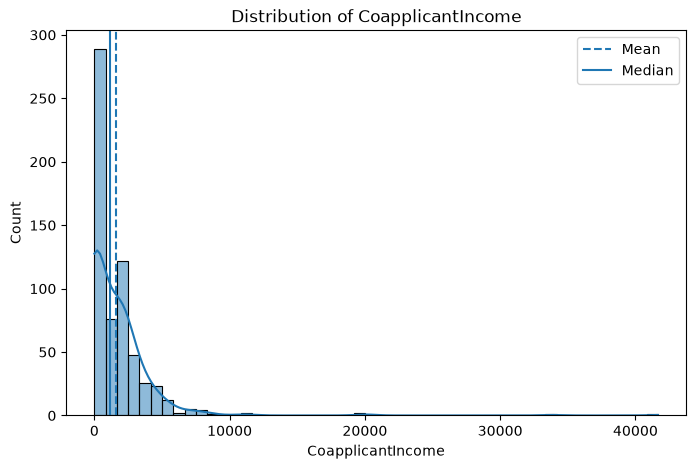

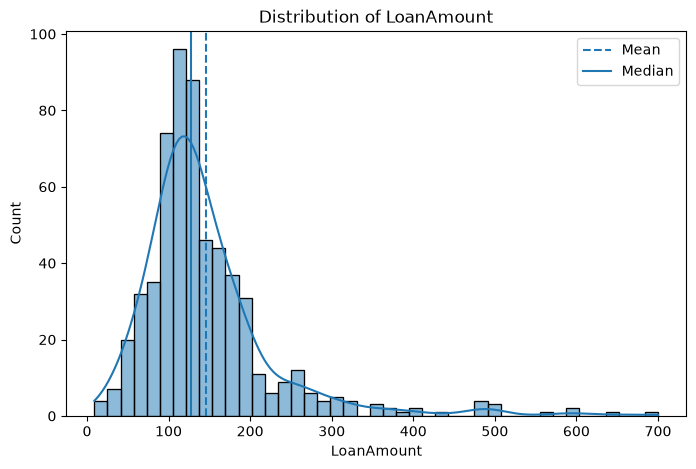

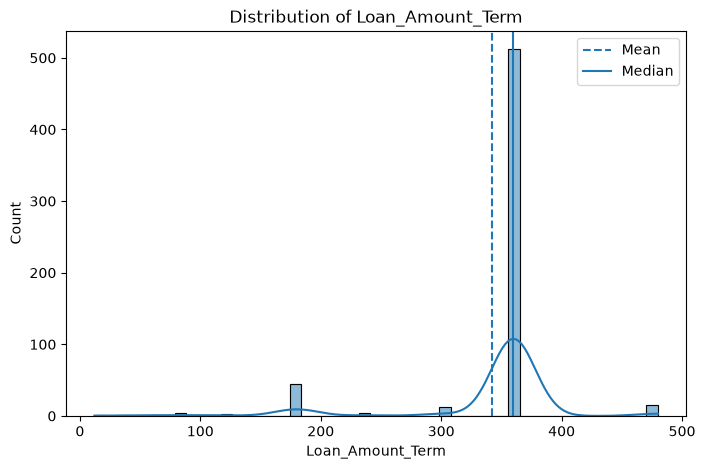

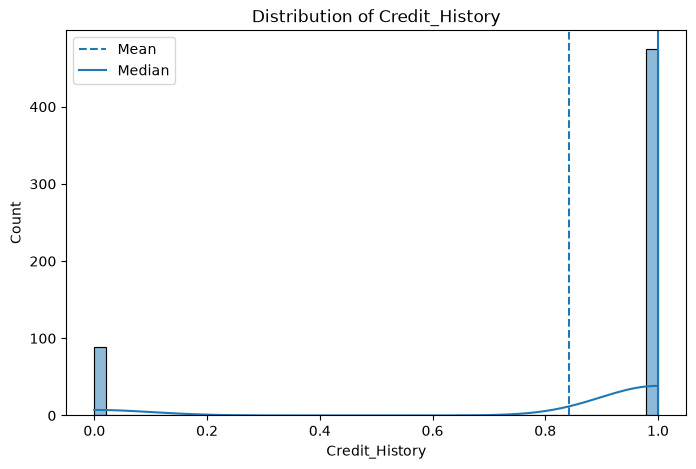

In [24]:
# plot histograms
for col in num_cols:
    plt.figure(figsize=(8,5))
    
    sns.histplot(
        data=train_copy,
        x=col,
        kde=True
        )
    
    plt.axvline(train_copy[col].mean(), linestyle='--', label='Mean')
    plt.axvline(train_copy[col].median(), linestyle='-', label='Median')
    
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

In [25]:
# identifying outliers
# calculate the lower and upper limits for identifying potential outliers
# 1.5 is the standard multiplier used with the IQR to define outlier boundaries

def main():
    identify_outliers()


def identify_outliers():
    
    q1 = num_cols.quantile(0.25)
    q3 = num_cols.quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    
    for col in num_cols:
        
        # select the values in num_cols[col] that are below the lower limit
        lower_outliers = num_cols[col][num_cols[col] < lower_limit[col]]
        
        # select the values in num_cols[col] that are above the upper limit
        upper_outliers = num_cols[col][num_cols[col] > upper_limit[col]]
        
        print(f'\n{col}')
        
        # print the calculated lower limit for the current column
        print(f'Lower Limit: {lower_limit[col]}')
        
        # print the lower outliers after converting them to a list
        print(f'Lower Outliers: {lower_outliers.tolist()}')
        
        
        # print the calculated upper limit for the current column
        print(f'\nUpper Limit: {upper_limit[col]}')
        
        # print the upper outliers after converting them to a list
        print(f'Upper Outliers: {upper_outliers.tolist()}')
        

main()


ApplicantIncome
Lower Limit: -1498.75
Lower Outliers: []

Upper Limit: 10171.25
Upper Outliers: [12841, 12500, 11500, 10750, 13650, 11417, 14583, 10408, 23803, 10513, 20166, 14999, 11757, 14866, 39999, 51763, 33846, 39147, 12000, 11000, 16250, 14683, 11146, 14583, 20667, 20233, 15000, 63337, 19730, 15759, 81000, 14880, 12876, 10416, 37719, 16692, 16525, 16667, 10833, 18333, 17263, 20833, 13262, 17500, 11250, 18165, 19484, 16666, 16120, 12000]

CoapplicantIncome
Lower Limit: -3445.875
Lower Outliers: []

Upper Limit: 5743.125
Upper Outliers: [10968.0, 8106.0, 7210.0, 8980.0, 7750.0, 11300.0, 7250.0, 7101.0, 6250.0, 7873.0, 20000.0, 20000.0, 8333.0, 6667.0, 6666.0, 7166.0, 33837.0, 41667.0]

LoanAmount
Lower Limit: -2.0
Lower Outliers: []

Upper Limit: 270.0
Upper Outliers: [349.0, 315.0, 320.0, 286.0, 312.0, 370.0, 650.0, 290.0, 600.0, 275.0, 700.0, 495.0, 280.0, 279.0, 304.0, 330.0, 436.0, 480.0, 300.0, 376.0, 490.0, 308.0, 570.0, 380.0, 296.0, 275.0, 360.0, 405.0, 500.0, 480.0, 311.0

In [26]:
# identify number of outliers per numerical columns

def main():
    
    total_outliers()
    

def total_outliers():
        q1 = num_cols.quantile(0.25)
        q3 = num_cols.quantile(0.75)

        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr
        
        for col in num_cols:
            
            total_lower_outliers = (num_cols[col] < lower_limit[col]).sum()
            
            total_upper_outliers = (num_cols[col] > upper_limit[col]).sum()
            
            print(f'Total number of lower outliers in {col}: {total_lower_outliers} \n')
            print(f'Total number of upper outliers in {col}: {total_upper_outliers} \n')
            
main()

Total number of lower outliers in ApplicantIncome: 0 

Total number of upper outliers in ApplicantIncome: 50 

Total number of lower outliers in CoapplicantIncome: 0 

Total number of upper outliers in CoapplicantIncome: 18 

Total number of lower outliers in LoanAmount: 0 

Total number of upper outliers in LoanAmount: 39 

Total number of lower outliers in Loan_Amount_Term: 73 

Total number of upper outliers in Loan_Amount_Term: 15 

Total number of lower outliers in Credit_History: 89 

Total number of upper outliers in Credit_History: 0 



**Interpretations:**

- The IQR method identified potential outliers in several numerical variables. ApplicantIncome had 50 potential upper outliers, indicating that a subset of applicants reported substantially higher incomes than the majority of the dataset. LoanAmount also showed 39 potential upper outliers, suggesting that some applicants requested considerably larger loan amounts. CoapplicantIncome had 18 potential upper outliers, indicating fewer but still notable unusually high coapplicant incomes.

- Loan_Amount_Term showed 73 potential lower outliers and 15 potential upper outliers. However, these observations should not automatically be considered erroneous because loan terms are discrete values and are concentrated around certain standard terms. The IQR rule may therefore flag valid loan-term categories as potential outliers.

- Credit_History produced 89 potential lower outliers because the variable is binary (0 or 1). Since the IQR method is more appropriate for continuous numerical variables, these observations should not be treated as anomalous. Instead, Credit_History should be examined using its frequency or proportion of 0 and 1 values.

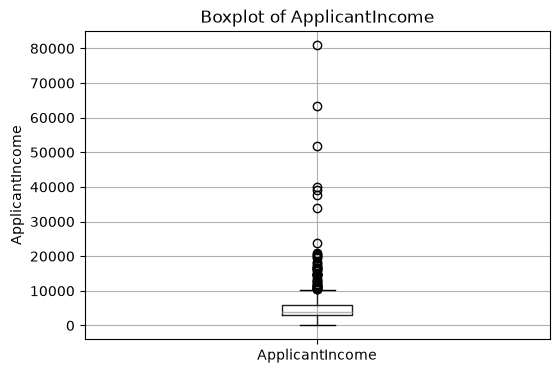

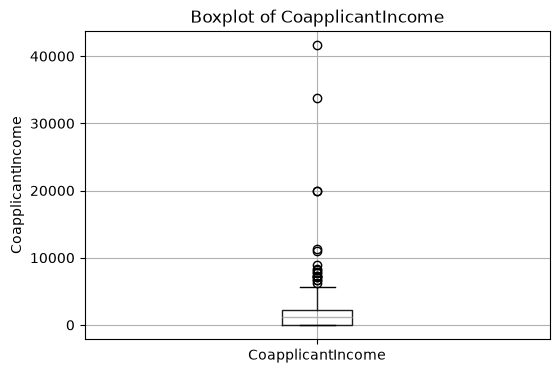

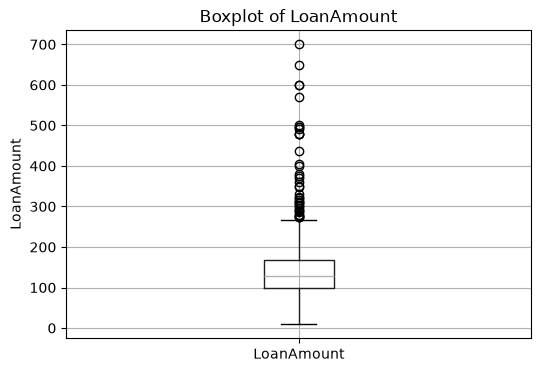

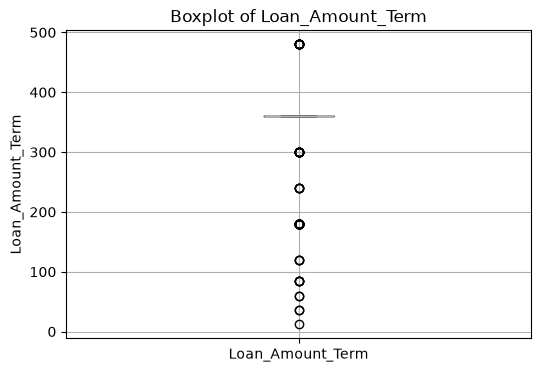

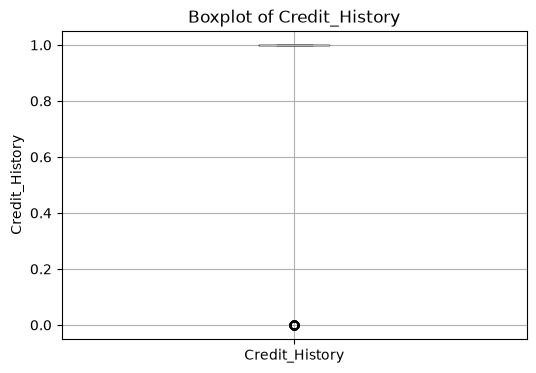

In [46]:
# plot boxplot

for col in num_cols.columns:
    
    plt.figure(figsize=(6,4))
    
    num_cols.boxplot(column=[col])
    
    plt.title(f'Boxplot of {col}')
    
    plt.ylabel(col)
    
    plt.show()

**Categorical Univariate Analysis**

This section explores the distribution of categorical features using:

- Frequency counts
- Visualize categorical distributions

In [45]:
# how many observations belong to each category?
for col in cat_cols:

    print("=====" * 10)
    
    print(train_copy[col].value_counts())

Gender
Male      489
Female    112
Name: count, dtype: int64
Married
Yes    398
No     213
Name: count, dtype: int64
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


In [44]:
# calculate percentages
for col in cat_cols:
    
    print("=====" * 10)
    
    print(train_copy[col].value_counts(normalize=True).mul(100).round(2))

Gender
Male      81.36
Female    18.64
Name: proportion, dtype: float64
Married
Yes    65.14
No     34.86
Name: proportion, dtype: float64
Dependents
0     57.60
1     17.03
2     16.86
3+     8.51
Name: proportion, dtype: float64
Education
Graduate        78.18
Not Graduate    21.82
Name: proportion, dtype: float64
Self_Employed
No     85.91
Yes    14.09
Name: proportion, dtype: float64
Property_Area
Semiurban    37.95
Urban        32.90
Rural        29.15
Name: proportion, dtype: float64


**Interpretations:**

* **Gender:** The dataset is predominantly composed of male applicants, accounting for **81.36%** of the observations, while female applicants account for **18.64%**. This indicates that there are substantially more male applicants than female applicants in the dataset.

* **Married:** **65.14%** of the applicants are married, while **34.86%** are unmarried. This shows that married applicants make up the majority of the dataset.

* **Dependents:** Applicants with **0 dependents** make up the largest group, accounting for **57.60%** of the dataset. Applicants with **1 dependent** account for **17.03%**, while those with **2 dependents** account for **16.86%**. Applicants with **3+ dependents** make up the smallest group at **8.51%**. Overall, the dataset is predominantly composed of applicants with no dependents.

* **Education:** **78.18%** of applicants are graduates, while **21.82%** are non-graduates. This indicates that graduates make up a substantial majority of the dataset.

* **Self-Employed:** **85.91%** of applicants are not self-employed, while **14.09%** are self-employed. This indicates that the dataset is heavily dominated by applicants who are not self-employed.

* **Property Area:** **37.95%** of applicants are from semiurban areas, **32.90%** are from urban areas, and **29.15%** are from rural areas. The distribution is relatively more balanced compared with the other categorical variables, although semiurban applicants represent the largest group.


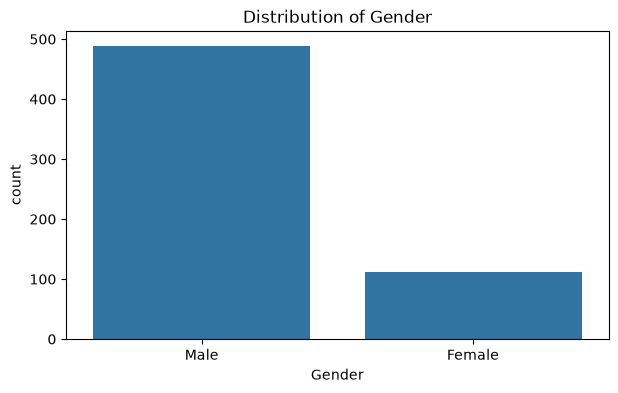

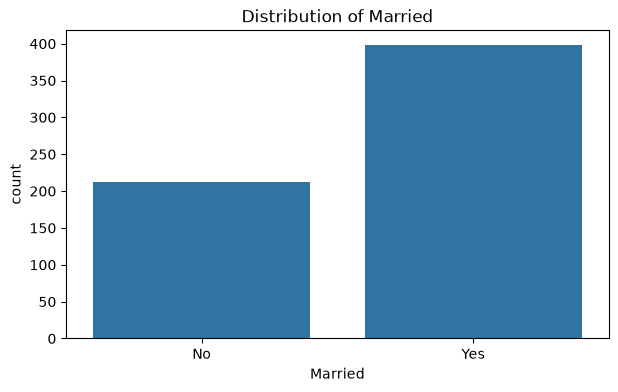

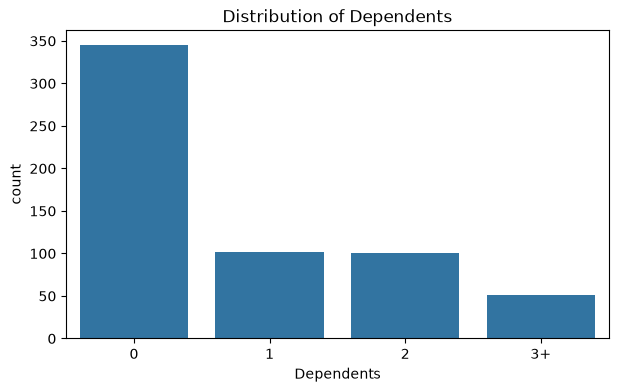

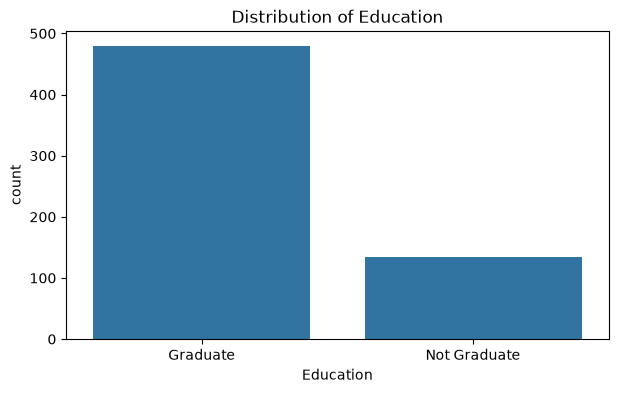

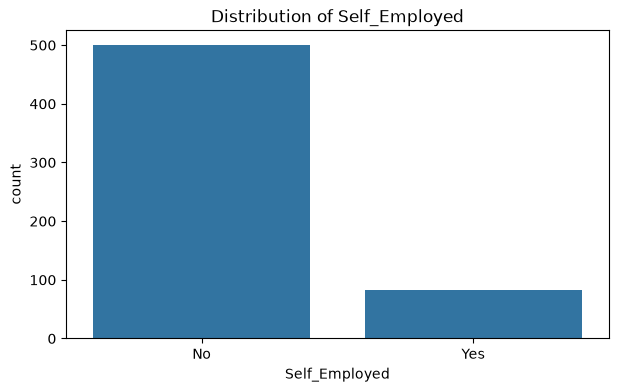

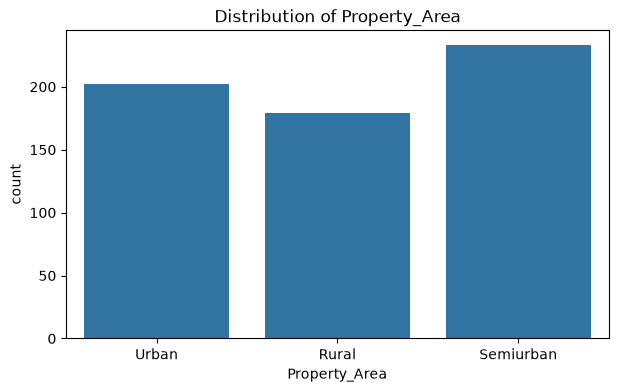

In [30]:
# plot count plots

for col in cat_cols:
    
    plt.figure(figsize=(7,4))
    
    sns.countplot(
        data=train_df,
        x=col
    )
    
    plt.title(f'Distribution of {col}')
    plt.show()

**Target Variable Inspection**

This section aims to understand the distribution of the target variable, Loan_Status, using:

- Frequency counts
- Percentage distribution
- Count plot

In [43]:
# inspect target feature
print(train_copy['Loan_Status'].value_counts())

print("=====" * 10)

print(
    train_copy['Loan_Status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Loan_Status
Y    422
N    192
Name: count, dtype: int64
Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64


**Interpretation:**

* There are 422 loan applications (68.73%) that received a "Yes" approval status and 192 applications (31.27%) that received a "No" status, out of 614 total applications. This indicates that the target variable, Loan_Status, is imbalanced, with approved applications occurring more frequently than rejected applications. The "Yes" class accounts for more than twice the number of applications in the "No" class.


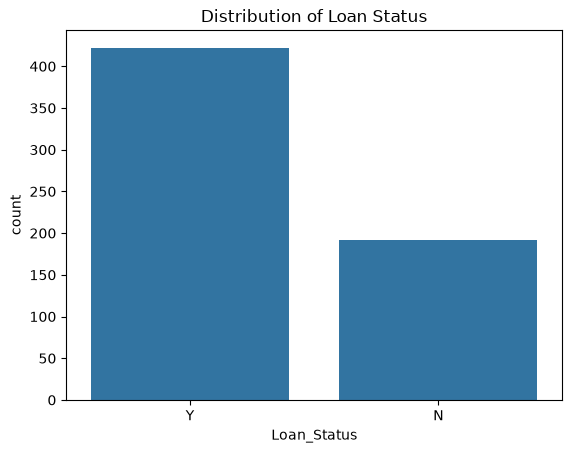

In [32]:
# plot count plot
sns.countplot(
    data=train_copy, x='Loan_Status'
)

plt.title('Distribution of Loan Status')

plt.show()


**Bivariate Analysis: Categorical Features vs Loan Status**

In [41]:
# bivariate analysis cross tab

for col in cat_cols:
    
    print("=====" * 10)
    print(f'{col}')
    
    print(
        pd.crosstab(
            train_copy[col],
            train_copy['Loan_Status']
        )
    )

Gender
Loan_Status    N    Y
Gender               
Female        37   75
Male         150  339
Married
Loan_Status    N    Y
Married              
No            79  134
Yes          113  285
Dependents
Loan_Status    N    Y
Dependents           
0            107  238
1             36   66
2             25   76
3+            18   33
Education
Loan_Status     N    Y
Education             
Graduate      140  340
Not Graduate   52   82
Self_Employed
Loan_Status      N    Y
Self_Employed          
No             157  343
Yes             26   56
Property_Area
Loan_Status     N    Y
Property_Area         
Rural          69  110
Semiurban      54  179
Urban          69  133


In [40]:
# proportion for bivariate analysis cross tab

for col in cat_cols:
    print("=====" * 10)
    print(f'{col}')
    
    print(
        pd.crosstab(
            train_copy[col],
            train_copy['Loan_Status'],
            normalize='index'
        ).mul(100).round(2)
    )

Gender
Loan_Status      N      Y
Gender                   
Female       33.04  66.96
Male         30.67  69.33
Married
Loan_Status      N      Y
Married                  
No           37.09  62.91
Yes          28.39  71.61
Dependents
Loan_Status      N      Y
Dependents               
0            31.01  68.99
1            35.29  64.71
2            24.75  75.25
3+           35.29  64.71
Education
Loan_Status       N      Y
Education                 
Graduate      29.17  70.83
Not Graduate  38.81  61.19
Self_Employed
Loan_Status        N      Y
Self_Employed              
No             31.40  68.60
Yes            31.71  68.29
Property_Area
Loan_Status        N      Y
Property_Area              
Rural          38.55  61.45
Semiurban      23.18  76.82
Urban          34.16  65.84


**Interpretations:**


* **Gender:** Among female applicants, **66.96% received an approved loan status**, while **33.04% were rejected**. Among male applicants, **69.33% received an approved loan status**, while **30.67% were rejected**. This indicates that male applicants had a slightly higher approval rate than female applicants in this dataset.

* **Married:** Among married applicants, **71.61% received an approved loan status**, while **28.39% were rejected**. Among unmarried applicants, **62.91% were approved**, while **37.09% were rejected**. This indicates that married applicants had a higher approval rate than unmarried applicants.

* **Dependents:** Among applicants with **0 dependents**, **68.99% received an approved loan status**, while **31.01% were rejected**. For applicants with **1 dependent**, **64.71% were approved**, while **35.29% were rejected**. Applicants with **2 dependents had the highest approval rate at 75.25%**, with 24.75% rejected. Among applicants with **3+ dependents**, **64.71% were approved**, while **35.29% were rejected**. Overall, applicants with 2 dependents had the highest approval rate, while applicants with 1 or 3+ dependents had the lowest approval rate.

* **Education:** Among graduate applicants, **70.83% received an approved loan status**, while **29.17% were rejected**. Among non-graduate applicants, **61.19% were approved**, while **38.81% were rejected**. This indicates that graduate applicants had a higher approval rate than non-graduate applicants.

* **Self-Employed:** Among applicants who were not self-employed, **68.60% received an approved loan status**, while **31.40% were rejected**. Among self-employed applicants, **68.29% were approved**, while **31.71% were rejected**. The approval rates are very similar between the two groups, suggesting that self-employment status shows little difference in loan approval rates in this dataset.

* **Property Area:** Among applicants from rural areas, **61.45% received an approved loan status**, while **38.55% were rejected**. Among applicants from semiurban areas, **76.82% were approved**, while **23.18% were rejected**. Among applicants from urban areas, **65.84% were approved**, while **34.16% were rejected**. This indicates that semiurban applicants had the highest approval rate, while rural applicants had the lowest approval rate among the three property-area categories.

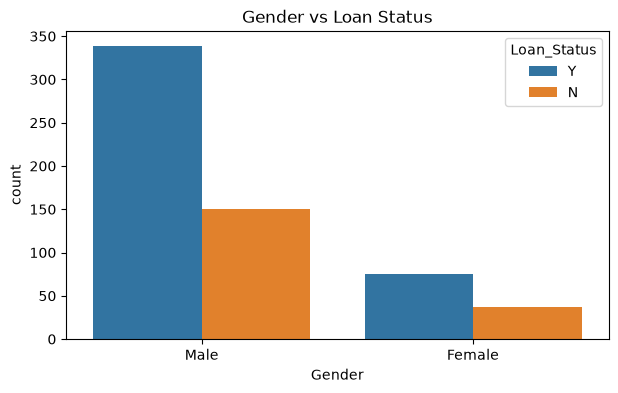

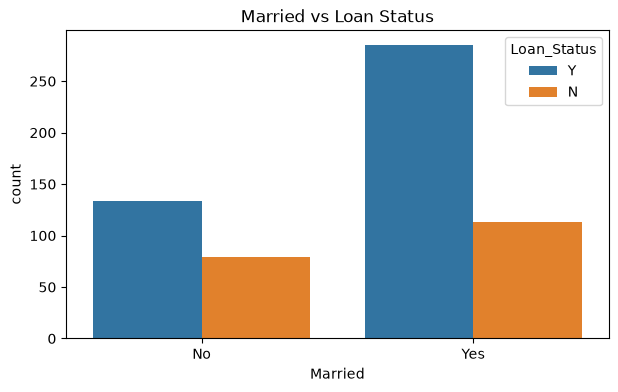

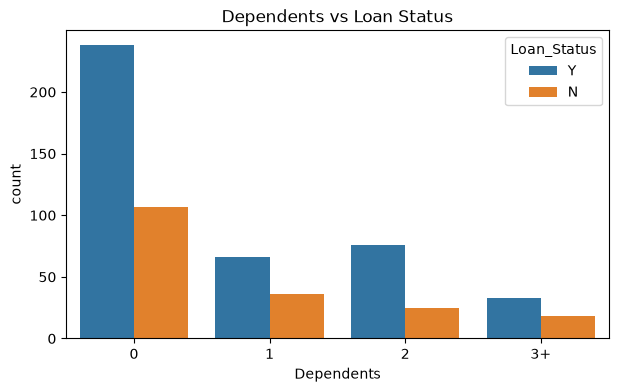

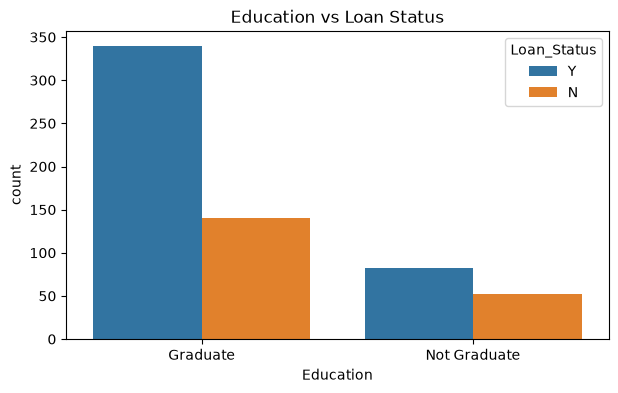

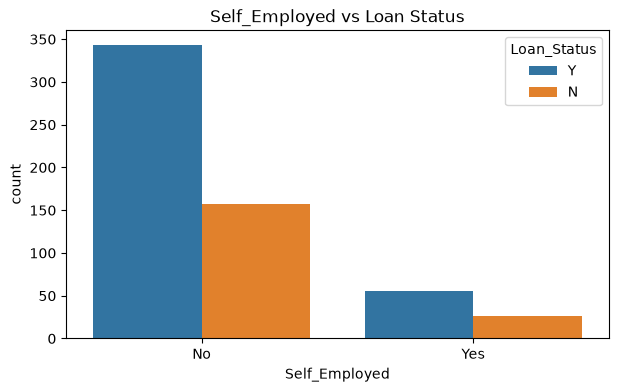

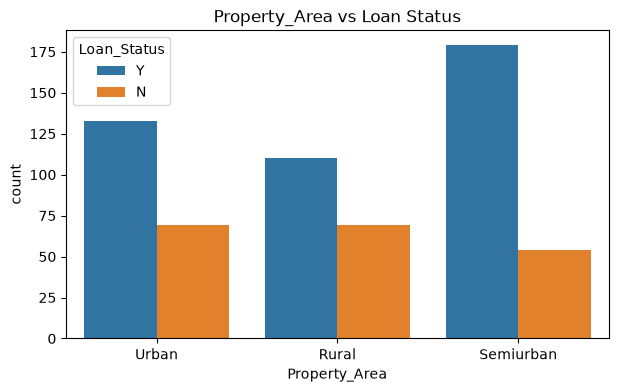

In [35]:
# count plot for categorical features vs. Loan_Status

for col in cat_cols:
    
    plt.figure(figsize=(7,4))
    
    sns.countplot(
        data=train_copy, 
        x=col, 
        hue='Loan_Status'
    )
    
    plt.title(f'{col} vs Loan Status')
    
    plt.show()

**Bivariate Analysis: Numerical Features vs Loan Status**

In [36]:
# group statistics

for col in num_cols.columns:
    
    print("=====" * 10)
    print(f'{col}')
    
    print(
        train_copy.groupby('Loan_Status')[col]
        .agg(
            [
                'count',
                'mean',
                'median',
                'std'
            ]
        ).round(2)
    )

ApplicantIncome
             count     mean  median      std
Loan_Status                                 
N              192  5446.08  3833.5  6819.56
Y              422  5384.07  3812.5  5765.44
CoapplicantIncome
             count     mean  median      std
Loan_Status                                 
N              192  1877.81   268.0  4384.06
Y              422  1504.52  1239.5  1924.75
LoanAmount
             count    mean  median    std
Loan_Status                              
N              181  151.22   129.0  85.86
Y              411  144.29   126.0  85.48
Loan_Amount_Term
             count    mean  median    std
Loan_Status                              
N              186  344.06   360.0  69.24
Y              414  341.07   360.0  63.25
Credit_History
             count  mean  median   std
Loan_Status                           
N              179  0.54     1.0  0.50
Y              385  0.98     1.0  0.13


**Interpretations:**

- **ApplicantIncome:** The mean and median applicant incomes are very similar between approved and rejected loans. Rejected applicants have a slightly higher mean and median income than approved applicants. However, the difference is small, suggesting that applicant income alone does not show a strong difference between the two loan-status groups.

- **CoapplicantIncome:** Rejected applicants have a higher mean coapplicant income than approved applicants, but their median is substantially lower. This large difference between the mean and median for rejected applicants suggests that a small number of applicants with very high coapplicant incomes are influencing the average. The higher standard deviation for rejected applicants also indicates greater variability.

- **LoanAmount:** The mean and median loan amounts are slightly higher for rejected applicants compared with approved applicants. However, the differences are small, while the standard deviations are almost identical. This suggests that the distribution of loan amounts is relatively similar between the two loan-status groups.

- **Loan_Amount_Term:** The mean loan term is slightly higher for rejected applicants, while the median is 360 months for both groups. The similar medians indicate that 360 months is the typical loan term for both approved and rejected applicants. The standard deviations are also relatively similar, suggesting comparable variability between the two groups.

- **Credit_History:** Approved applicants have a substantially higher mean credit history value (0.98) compared with rejected applicants (0.54). Since Credit_History is a binary variable, this indicates that approximately 98% of approved applicants had a credit history value of 1, compared with approximately 54% of rejected applicants. This suggests that credit history has a strong relationship with loan status in this dataset.







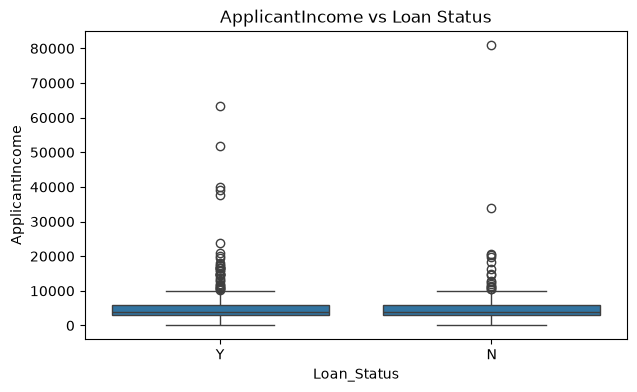

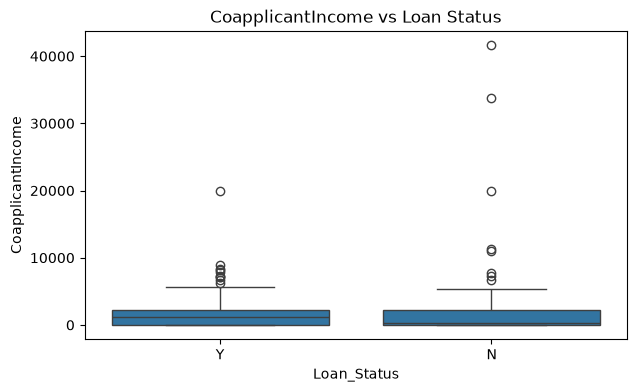

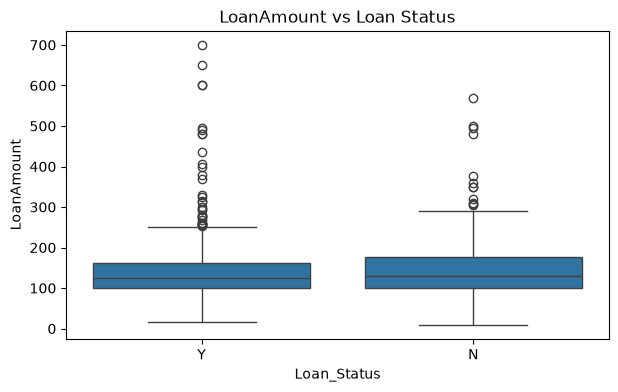

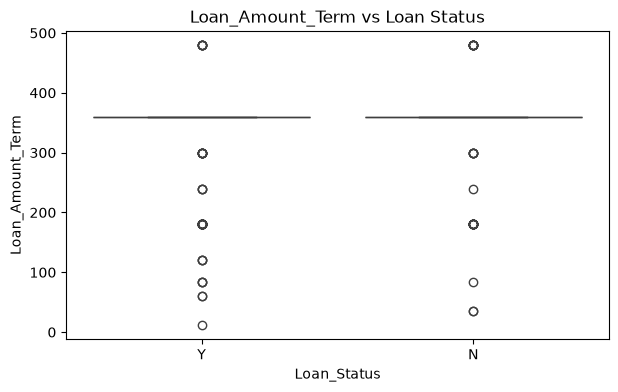

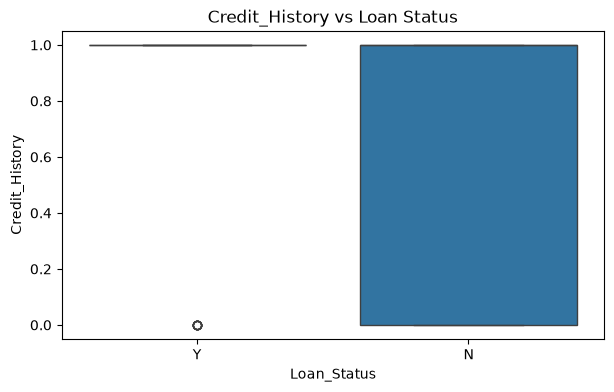

In [37]:
# numerical features vs Loan_Status

for col in num_cols:
    
    plt.figure(figsize=(7,4))
    
    sns.boxplot(
        data=train_copy,
        x='Loan_Status',
        y=col
    )
    
    plt.title(f'{col} vs Loan Status')
    
    plt.show()

**Correlation Matrix of Numerical Features**

In [38]:
# calculate the correlation matrix
num_cols.corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000


**Interpretations:**

- ApplicantIncome and LoanAmount have a moderate positive linear relationship, with a correlation of 0.57. This indicates that the two features tend to move in the same direction, with higher applicant incomes tending to be associated with higher loan amounts.

- CoapplicantIncome and LoanAmount have a very weak positive linear relationship, with a correlation of 0.19. This suggests that higher coapplicant incomes tend to be associated with slightly higher loan amounts, although the relationship is weak.

- LoanAmount and Loan_Amount_Term have a negligible positive linear relationship, with a correlation of 0.039, indicating little to no linear relationship between the two features.

- Loan_Amount_Term and Credit_History have a negligible positive linear correlation of 0.001, indicating essentially no linear relationship between the two features.

- The remaining numerical feature pairs also have correlations close to zero, indicating very weak or negligible linear relationships.

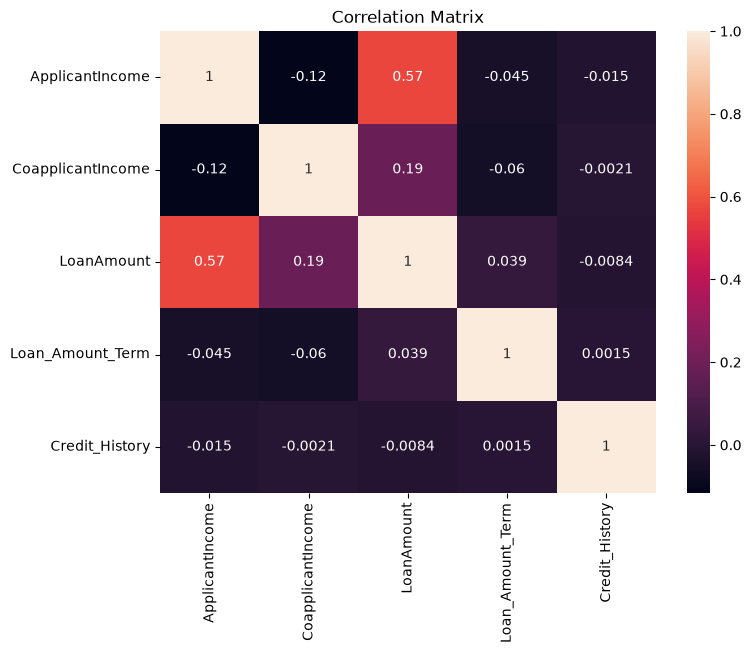

In [39]:
# correlation analysis

corr = num_cols.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True)

plt.title('Correlation Matrix')

plt.show()

**Conclusion**

This notebook performed exploratory data analysis on the **Analytics Vidhya: Loan Prediction** dataset by Anmol Kumar, obtained from Kaggle. The dataset contains 614 rows and 13 columns and is intended to be used for predicting loan eligibility using a machine learning approach. Several features contain missing values, which will be addressed during the preprocessing phase in the `bank_loan_prediction` notebook.

The dataset contains 422 approved loan applications (Y) and 192 rejected applications (N). This indicates that the target variable is moderately imbalanced, with approximately 69% of applications approved and 31% rejected.

For the categorical features, the dataset is predominantly composed of male applicants (81.36%), married applicants (65.14%), applicants with no dependents (57.60%), graduate applicants (78.18%), non-self-employed applicants (85.91%), and applicants from semiurban areas (37.95%).

The categorical features also showed differences in loan approval rates. Married applicants had a higher approval rate than unmarried applicants, while applicants with 2 dependents had the highest approval rate among the dependents categories. Graduate applicants also had a higher approval rate than non-graduate applicants. In contrast, the approval rates between self-employed and non-self-employed applicants were very similar. Property_Area showed the largest difference in approval rates, with Semiurban applicants having the highest approval rate at 76.82% and Rural applicants having the lowest at 61.45%, a difference of 15.37 percentage points. Self_Employed showed the smallest difference, with approval rates of 68.60% for non-self-employed applicants and 68.29% for self-employed applicants, a difference of only 0.31 percentage points.

The numerical features showed varying distributions. ApplicantIncome, CoapplicantIncome, and LoanAmount were right-skewed, with skewness values of 6.54, 7.49, and 2.68, respectively. Loan_Amount_Term had a negative skewness value of -2.36, indicating a left-skewed distribution. ApplicantIncome and CoapplicantIncome also showed noticeable differences between their means and medians, which is consistent with their strong positive skewness.

ApplicantIncome and CoapplicantIncome showed the greatest variability among the continuous numerical features, with standard deviations of 6,109.04 and 2,926.25, respectively. The high variability and strong skewness of these income variables indicate that some applicants have substantially higher incomes than the majority of the dataset.

The IQR method identified potential outliers in several numerical variables. ApplicantIncome had 50 potential upper outliers, while LoanAmount had 39 and CoapplicantIncome had 18. Loan_Amount_Term had 73 potential lower outliers and 15 potential upper outliers. However, these observations should not automatically be considered erroneous because loan terms are discrete values and are concentrated around certain standard terms. The IQR method may therefore flag valid loan-term values as potential outliers. Credit_History produced 89 potential lower outliers, but since it is a binary variable with values of 0 and 1, the IQR method is not appropriate for identifying anomalies in this feature. Its distribution is better examined using frequencies or proportions.

ApplicantIncome, LoanAmount, and Loan_Amount_Term appeared relatively similar between approved and rejected applicants, as their means and medians were close across the two groups. Credit_History showed the clearest difference between approved and rejected applicants. The mean Credit_History was 0.54 among rejected applicants compared with 0.98 among approved applicants, indicating a substantial difference in the proportion of applicants with a positive credit history between the two groups.

Correlation analysis showed that ApplicantIncome and LoanAmount had the strongest positive linear relationship among the numerical features, with a correlation coefficient of 0.57. This indicates a moderate positive linear relationship, meaning that applicants with higher incomes tend to have higher loan amounts. The remaining numerical feature pairs showed weak or negligible linear relationships.

There were also no meaningful linear relationships between Credit_History and the other numerical features. All correlation coefficients were very close to zero, indicating negligible linear relationships. The correlation between Credit_History and Loan_Amount_Term was approximately 0.001, while its correlations with the other numerical features were also close to zero.

Overall, the EDA provided an initial understanding of the dataset's distributions, categorical composition, potential outliers, differences in loan approval rates, and relationships between numerical features. These findings provide useful context for the subsequent preprocessing and machine learning analysis conducted in the `bank_loan_prediction` notebook.